In [1]:
# =====================================
# Helper Functions for Dataset Exploration
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import f_classif, mutual_info_classif
import umap
from pandas.plotting import parallel_coordinates

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

print("import succussefully")

# def explore_dataset_complete(df, dataset_name="Dataset", top_n_features=10):
#     """
#     Explore dataset with numeric standardization, correlation, violin/boxplots,
#     PCA, t-SNE, UMAP, pairplots, class-wise KDE, ANOVA, mutual info, parallel coords.
#     """
#     print(f"\n=== Exploring {dataset_name} ===")
    
#     # Clean column names
#     df.columns = df.columns.str.strip()
    
#     # Detect target column
#     possible_targets = [col for col in df.columns if 'target' in col.lower() or 'marker' in col.lower()]
#     if len(possible_targets) == 0:
#         raise ValueError(f"No target column found in {dataset_name}")
#     target_col = possible_targets[0]
#     print(f"Detected target column: {target_col}")
    
#     # Encode target
#     df['target_num'] = df[target_col].astype('category').cat.codes
    
#     # Overview
#     print("\n-- Info --")
#     print(df.info())
#     print("\n-- Descriptive Statistics --")
#     print(df.describe().T)
    
#     # Handle missing values (numeric)
#     numeric_cols = df.select_dtypes(include='number').drop(columns=['target_num'])
#     df[numeric_cols.columns] = df[numeric_cols.columns].fillna(df[numeric_cols.columns].median())
    
#     # Standardize
#     scaler = StandardScaler()
#     df[numeric_cols.columns] = scaler.fit_transform(numeric_cols)
#     print("✅ Numeric features standardized")
    
#     # Class distribution
#     print("\n-- Class Distribution --")
#     print(df[target_col].value_counts())
#     print(df[target_col].value_counts(normalize=True)*100)
    
#     plt.figure(figsize=(6,4))
#     sns.countplot(x=target_col, data=df, palette="Set2")
#     plt.title(f"{dataset_name} Target Distribution")
#     plt.show()
    
#     # Correlation with target
#     corr_target = df[numeric_cols.columns].corrwith(df['target_num']).sort_values(ascending=False)
    
#     # Top features
#     top_features = corr_target.abs().sort_values(ascending=False).head(top_n_features).index.tolist()
    
#     return df, numeric_cols.columns, target_col, corr_target, top_features


import succussefully


In [2]:
# -------------------------------
# 0. LOOKUP Dictionary
# -------------------------------
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "Data Injection: L1 Fault 10–19% with tripping",
    8:  "Data Injection: L1 Fault 20–79% with tripping",
    9:  "Data Injection: L1 Fault 80–90% with tripping",
    10: "Data Injection: L2 Fault 10–19% with tripping",
    11: "Data Injection: L2 Fault 20–79% with tripping",
    12: "Data Injection: L2 Fault 80–90% with tripping",

    # Remote Tripping Attacks (15–20)
    15: "Remote Tripping: Command Injection R1",
    16: "Remote Tripping: Command Injection R2",
    17: "Remote Tripping: Command Injection R3",
    18: "Remote Tripping: Command Injection R4",
    19: "Remote Tripping: Command Injection R1 & R2",
    20: "Remote Tripping: Command Injection R3 & R4",

    # Relay Setting Change (21–30)
    21: "Relay Setting Change: R1 disabled (L1 10–19% fault)",
    22: "Relay Setting Change: R1 disabled (L1 20–90% fault)",
    23: "Relay Setting Change: R2 disabled (L1 10–49% fault)",
    24: "Relay Setting Change: R2 disabled (L1 50–79% fault)",
    25: "Relay Setting Change: R2 disabled (L1 80–90% fault)",
    26: "Relay Setting Change: R3 disabled (L2 10–19% fault)",
    27: "Relay Setting Change: R3 disabled (L2 20–49% fault)",
    28: "Relay Setting Change: R3 disabled (L2 50–90% fault)",
    29: "Relay Setting Change: R4 disabled (L2 10–79% fault)",
    30: "Relay Setting Change: R4 disabled (L2 80–90% fault)",

    # Relay Setting Change (two relays + fault)
    35: "Relay Setting Change: R1 & R2 disabled (L1 10–49% fault)",
    36: "Relay Setting Change: R1 & R2 disabled (L1 50–90% fault)",
    37: "Relay Setting Change: R3 & R4 disabled (L1 10–49% fault)",
    38: "Relay Setting Change: R3 & R4 disabled (L1 50–90% fault)",

    # Relay Setting Change (two relays + maintenance)
    39: "Relay Setting Change: R1 & R2 disabled during maintenance",
    40: "Relay Setting Change: R1 & R2 disabled during maintenance",

    # Normal Operation
    41: "Normal Operation (no disturbances)"
}

DI_NAMES = {
    7: "DI: Fault 10–19% L1",
    8: "DI: Fault 20–79% L1",
    9: "DI: Fault 80–90% L1",
    10: "DI: Fault 10–19% L2",
    11: "DI: Fault 20–79% L2",
    12: "DI: Fault 80–90% L2"
}

RT_NAMES = {
    15: "Remote Trip: Cmd R1",
    16: "Remote Trip: Cmd R2",
    17: "Remote Trip: Cmd R3",
    18: "Remote Trip: Cmd R4",
    19: "Remote Trip: Cmd R1 & R2",
    20: "Remote Trip: Cmd R3 & R4"
}

RSC_NAMES = {
    21: "RSC: L1 R1 Disabled (10–19%)",
    22: "RSC: L1 R1 Disabled (20–90%)",
    23: "RSC: L1 R2 Disabled (10–49%)", 
    24: "RSC: L1 R2 Disabled (50–79%)",
    25: "RSC: L1 R2 Disabled (80–90%)",
    26: "RSC: L2 R3 Disabled (10–19%)",
    27: "RSC: L2 R3 Disabled (20–49%)",
    28: "RSC: L2 R3 Disabled (50–90%)",
    29: "RSC: L2 R4 Disabled (10–79%)",
    30: "RSC: L2 R4 Disabled (80–90%)",
    35: "RSC: L1 R1&R2 Disabled (10–49%)",
    36: "RSC: L1 R1&R2 Disabled (50–90%)",
    37: "RSC: L1 R3&R4 Disabled (10–49%)",
    38: "RSC: L1 R3&R4 Disabled (50–90%)",
    39: "RSC: L1 Maint R1&R2 Disabled",
    40: "RSC: L1 Maint R1&R2 Disabled"
}


Shape: (78377, 129)
Total NaN: 0
Total INF: 10906


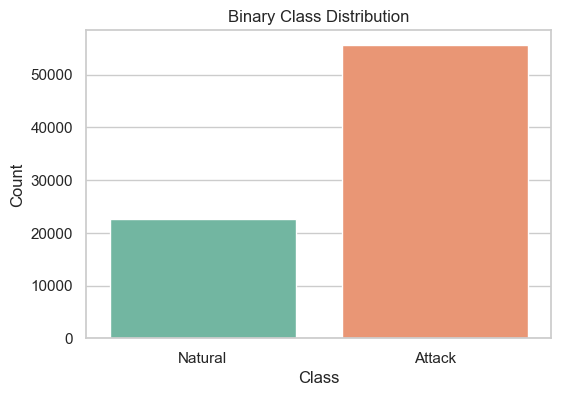


Top 10 Features:
['R2-PM1:V', 'R2-PM11:I', 'R3-PM11:I', 'R2-PM8:V', 'R3-PM8:V', 'R4-PM2:V', 'R2-PA6:IH', 'R2-PM12:I', 'R2-PM9:V', 'R1-PM11:I']
Top 7 Binary Features used for plots:
R2-PM1:V     0.051878
R2-PM11:I    0.049552
R3-PM11:I    0.048814
R2-PM8:V     0.048600
R3-PM8:V     0.048590
R4-PM2:V     0.046558
R2-PA6:IH    0.045472
dtype: float64


In [5]:
# ============================================================
# Load RAW dataset (inspection)
# ============================================================

binary_raw = pd.read_csv("../data/merged/binary_dataset.csv")
binary_raw.columns = binary_raw.columns.str.strip()

print("Shape:", binary_raw.shape)

print("Total NaN:", binary_raw.isna().sum().sum())

print(
    "Total INF:",
    np.isinf(
        binary_raw.select_dtypes(include=np.number)
    ).sum().sum()
)

# ============================================================
# 2. CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="marker",
    data=binary_raw,
    palette="Set2"
)

plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# ============================================================
# Encode target
# ============================================================

binary_raw["target_num"] = binary_raw[target_col].astype("category").cat.codes


# ============================================================
# Select numeric features
# ============================================================

numeric_cols = binary_raw.select_dtypes(include="number").columns

numeric_cols = [
    c for c in numeric_cols
    if c not in ["target_num", "marker", "Scenario_ID"]
    and "log" not in c.lower()
]


# ============================================================
# Correlation with target
# ============================================================

corr_target = (
    binary_raw[numeric_cols]
    .corrwith(binary_raw["target_num"])
    .abs()
    .sort_values(ascending=False)
)

top10_features = corr_target.head(10).index.tolist()

print("\nTop 10 Features:")
print(top10_features)

top7_binary = corr_target.head(7)

print("Top 7 Binary Features used for plots:")
print(top7_binary)

# top7_binary.to_json(
#     "../data/features/binary_top_features.json",
#     indent=4
# )


In [3]:
# ============================================================
# Load CLEAN dataset
# ============================================================

binary_df = pd.read_csv("../data/merged/binary_dataset_clean_FULL.csv")
binary_df.columns = binary_df.columns.str.strip()

target_col = "marker"

print("Clean dataset shape:", binary_df.shape)


# ============================================================
# Encode target
# ============================================================

binary_df["target_num"] = binary_df[target_col].astype("category").cat.codes


# ============================================================
# Select numeric features
# ============================================================

numeric_cols = binary_df.select_dtypes(include="number").columns

numeric_cols = [
    c for c in numeric_cols
    if c not in ["target_num", "marker", "Scenario_ID"]
    and "log" not in c.lower()
]


# ============================================================
# Correlation with target
# ============================================================

corr_target = (
    binary_df[numeric_cols]
    .corrwith(binary_df["target_num"])
    .abs()
    .sort_values(ascending=False)
)

top10_features = corr_target.head(10).index.tolist()

print("\nTop 10 Features:")
print(top10_features)

top7_binary = corr_target.head(7)

print("Top 7 Binary Features used for plots:")
print(top7_binary)

# top7_binary.to_json(
#     "../data/features/binary_top_features.json",
#     indent=4
# )

# ============================================================
# Scale features for visualization
# ============================================================

from sklearn.preprocessing import StandardScaler

viz_df = binary_df.copy()

scaler = StandardScaler()

viz_df[top_features] = scaler.fit_transform(viz_df[top_features])


# ============================================================
# Violin + Boxplots
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(top_features)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,5*n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_features):

    sns.violinplot(
        x=target_col,
        y=feat,
        data=viz_df,
        inner=None,
        palette="Set2",
        ax=axes[i]
    )

    sns.boxplot(
        x=target_col,
        y=feat,
        data=viz_df,
        width=0.25,
        showfliers=False,
        boxprops={'facecolor':'white','edgecolor':'black','linewidth':1.2},
        medianprops={'color':'red','linewidth':2},
        ax=axes[i]
    )

    axes[i].set_title(f"{feat} vs {target_col}")

for j in range(len(top_features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Top Features – Cleaned Distributions by Class", fontsize=18)

plt.tight_layout()
plt.show()


# ============================================================
# Pairplot
# ============================================================

sample_df = viz_df.sample(
    n=min(3000, len(viz_df)),
    random_state=42
)

sns.pairplot(
    sample_df[top_features + [target_col]],
    hue=target_col,
    palette="Set2",
    diag_kind="kde"
)

plt.suptitle("Pairplot – Binary Dataset", y=1.02)

plt.show()


# ============================================================
# KDE plots
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(top_features)/n_cols))

plt.figure(figsize=(14,5*n_rows))

for i, feature in enumerate(top_features):

    plt.subplot(n_rows, n_cols, i+1)

    sns.kdeplot(
        data=viz_df,
        x=feature,
        hue=target_col,
        fill=True,
        common_norm=False,
        palette="Set2",
        alpha=0.5
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

Clean dataset shape: (78377, 133)

Top 10 Features:
['R4-PM2:V', 'R4-PM7:V', 'R1-PA:ZH', 'R4-PA:ZH', 'R4-PM3:V', 'R4-PM1:V', 'R3-PM3:V', 'R2-PA:Z', 'R2-PA6:IH', 'R3-PA:Z']
Top 7 Binary Features used for plots:
R4-PM2:V    0.082166
R4-PM7:V    0.065059
R1-PA:ZH    0.058694
R4-PA:ZH    0.057791
R4-PM3:V    0.055355
R4-PM1:V    0.054344
R3-PM3:V    0.054272
dtype: float64


NameError: name 'top_features' is not defined

Dataset shape: (78377, 129)
Total NaN: 0
Total INF: 10906
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 129 entries, R1-PA1:VH to marker
dtypes: float64(113), int64(15), object(1)
memory usage: 77.1+ MB
Class counts:
marker
Attack      55663
Natural     18309
NoEvents     4405
Name: count, dtype: int64

Class percentages:
marker
Attack      71.019559
Natural     23.360169
NoEvents     5.620271
Name: proportion, dtype: float64


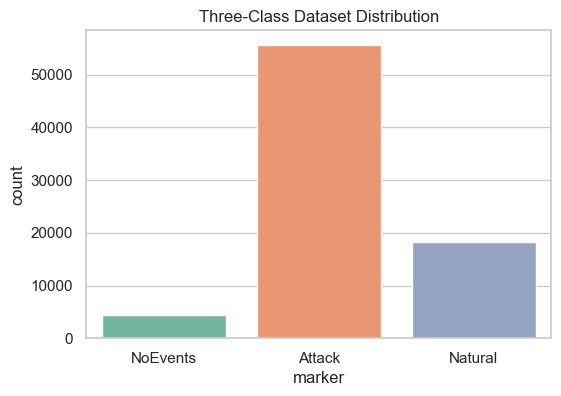

In [159]:
# ============================================================
# Three-Class Dataset – Clean EDA + Preprocessing Pipeline
# ============================================================

three_df_raw = pd.read_csv("../data/merged/three_class_dataset.csv")

three_df_raw.columns = three_df_raw.columns.str.strip()

print("Dataset shape:", three_df_raw.shape)

print("Total NaN:", three_df_raw.isna().sum().sum())

print(
    "Total INF:",
    np.isinf(
        three_df_raw.select_dtypes(include=np.number)
    ).sum().sum()
)


three_df_raw.head()

three_df_raw.info()

three_df_raw.describe().T.head(10)

print("Class counts:")
print(three_df_raw["marker"].value_counts())

print("\nClass percentages:")
print(three_df_raw["marker"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))

sns.countplot(
    x="marker",
    data=three_df_raw,
    palette="Set2"
)

plt.title("Three-Class Dataset Distribution")

plt.show()

Dataset shape: (78377, 133)

Top 10 features:
['R4-PM2:V', 'R4-PM7:V', 'R3-PM11:I', 'R2-PM11:I', 'R3-PM12:I', 'R1-PM12:I', 'R1-PM11:I', 'R4-PM12:I', 'R2-PM12:I', 'R4-PM11:I']
Top 7 Three-Class Features used for plots:
R4-PM2:V     0.116726
R4-PM7:V     0.089325
R3-PM11:I    0.086471
R2-PM11:I    0.086415
R3-PM12:I    0.085233
R1-PM12:I    0.085205
R1-PM11:I    0.084872
dtype: float64


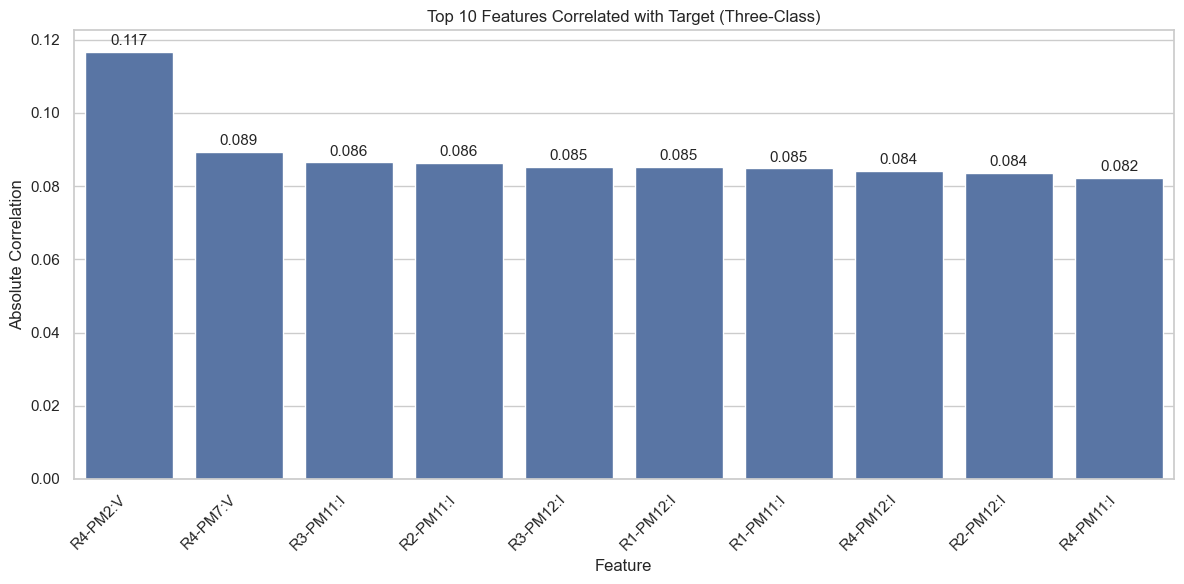

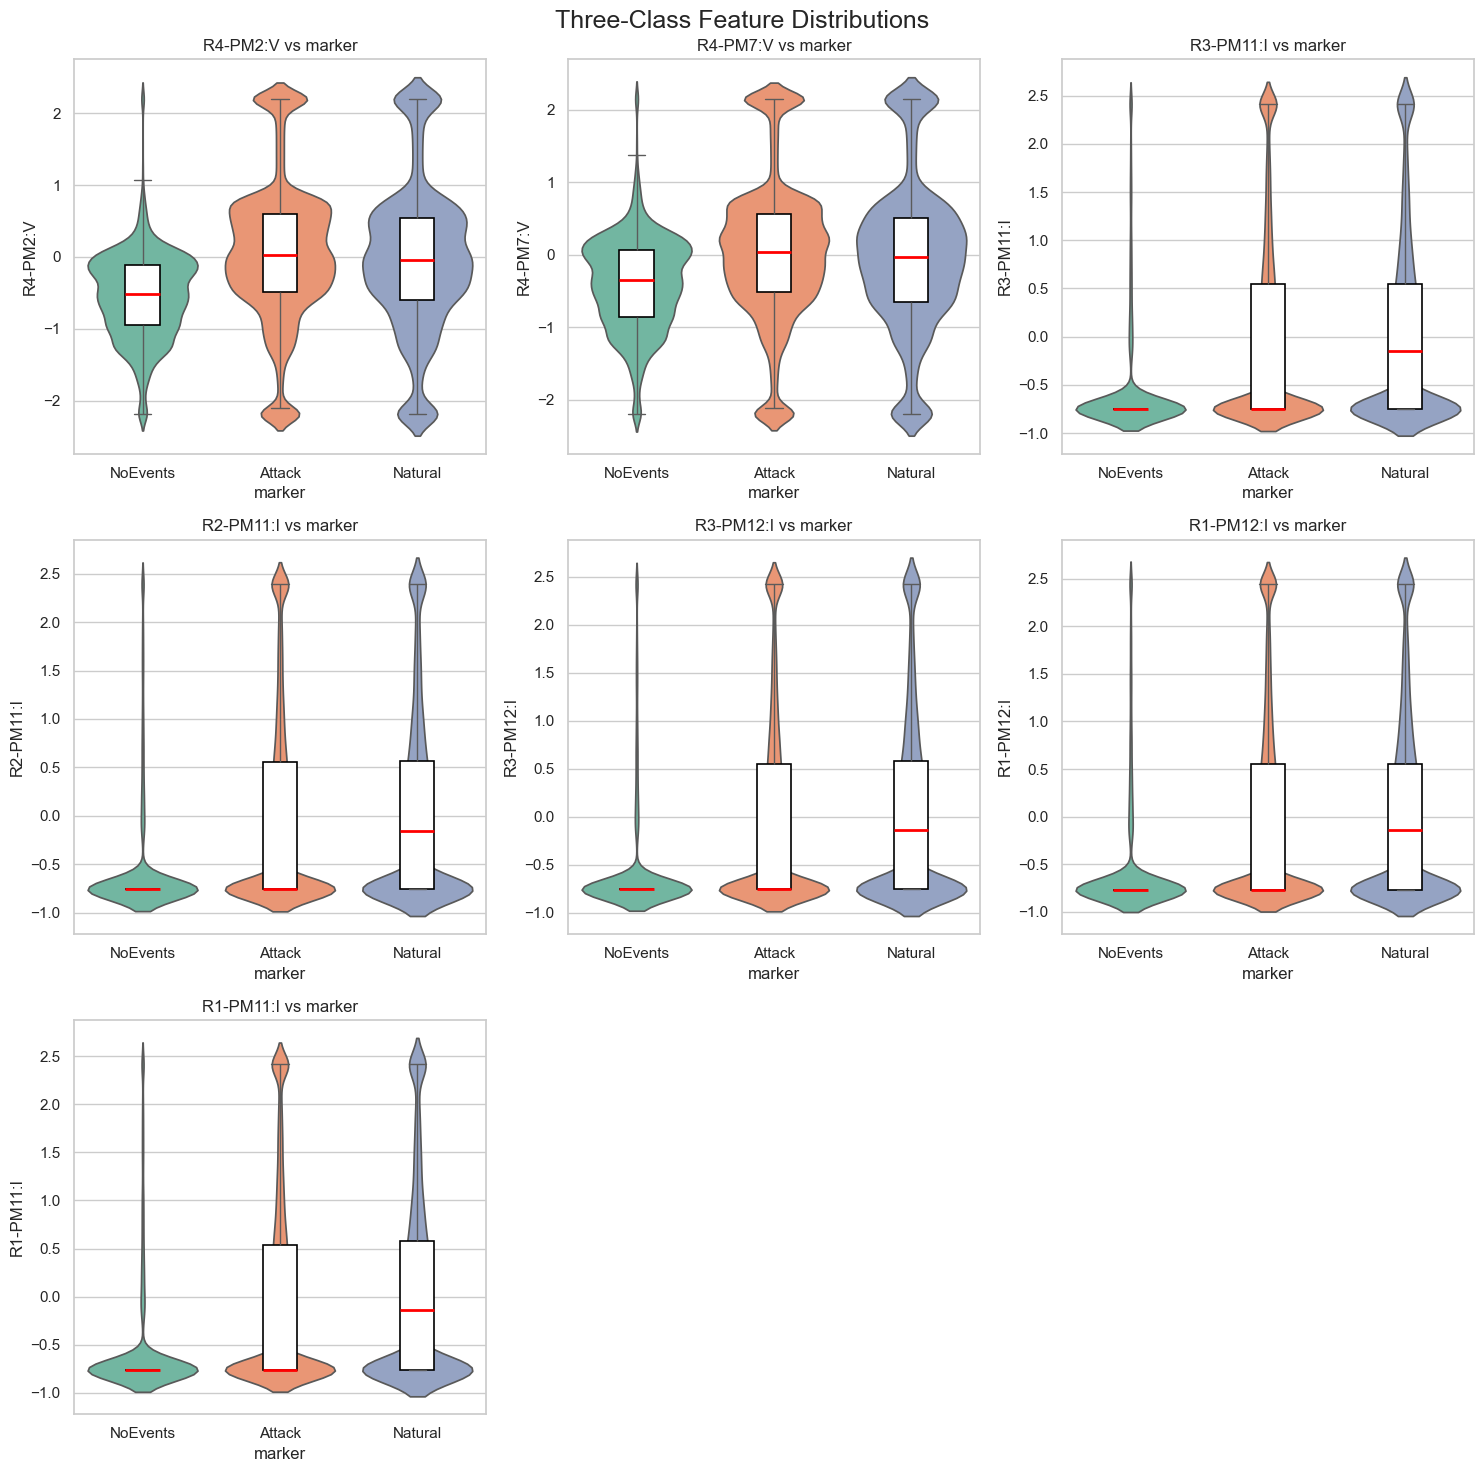

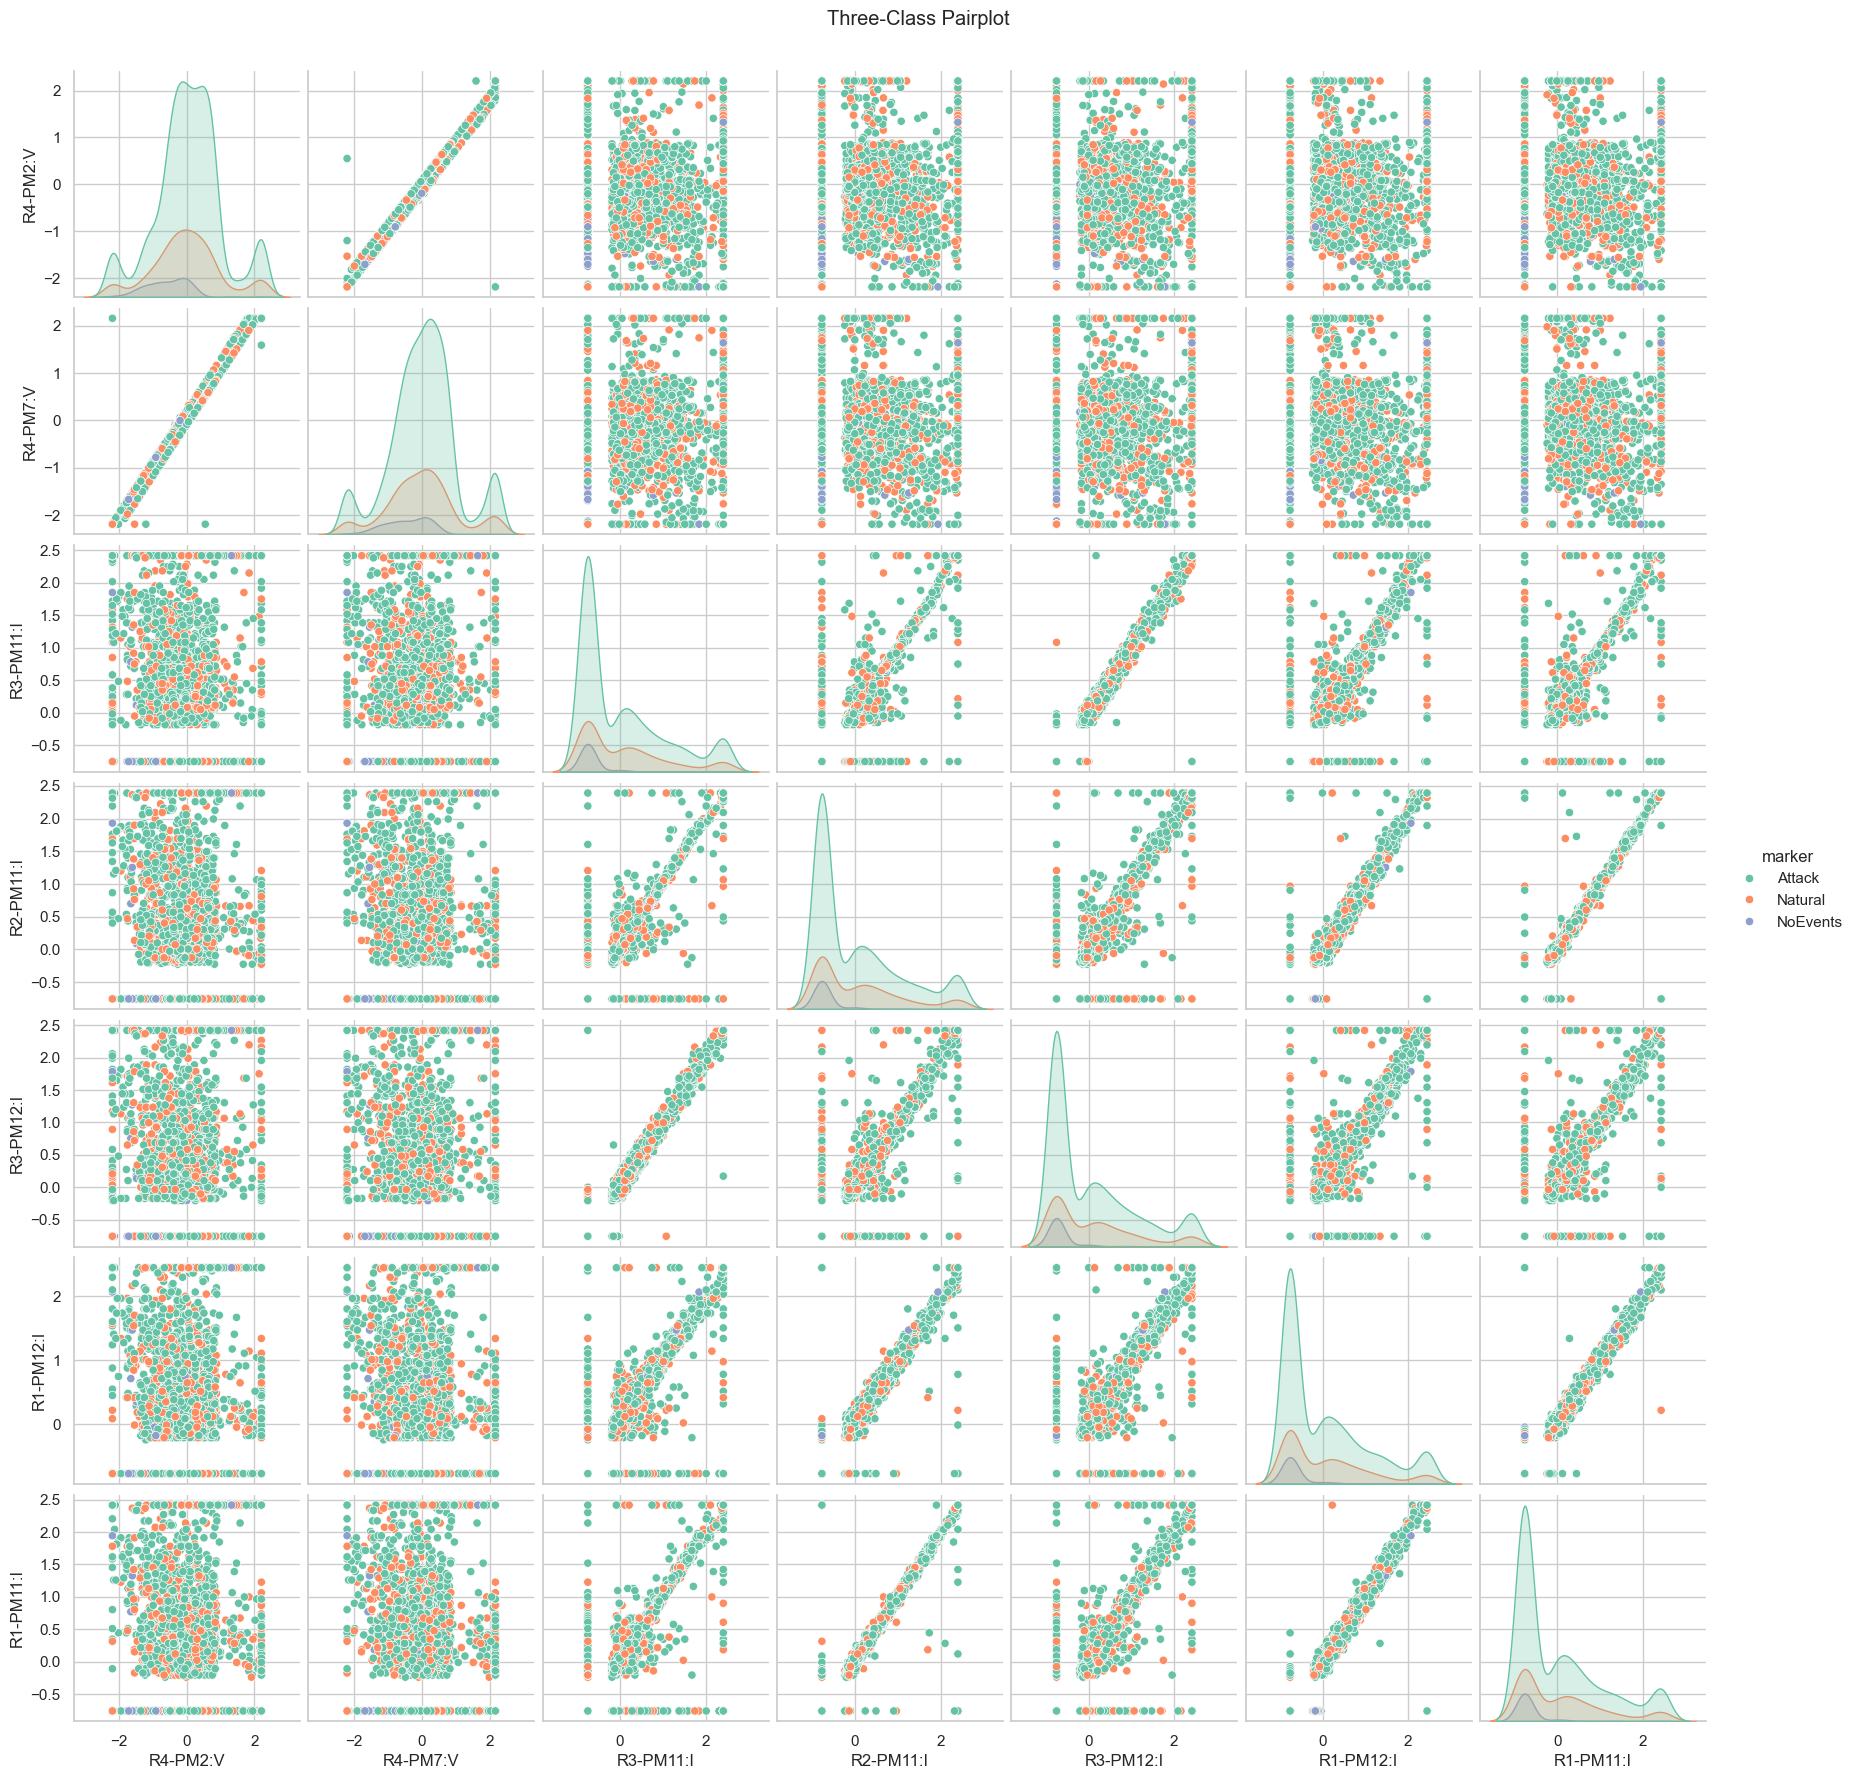

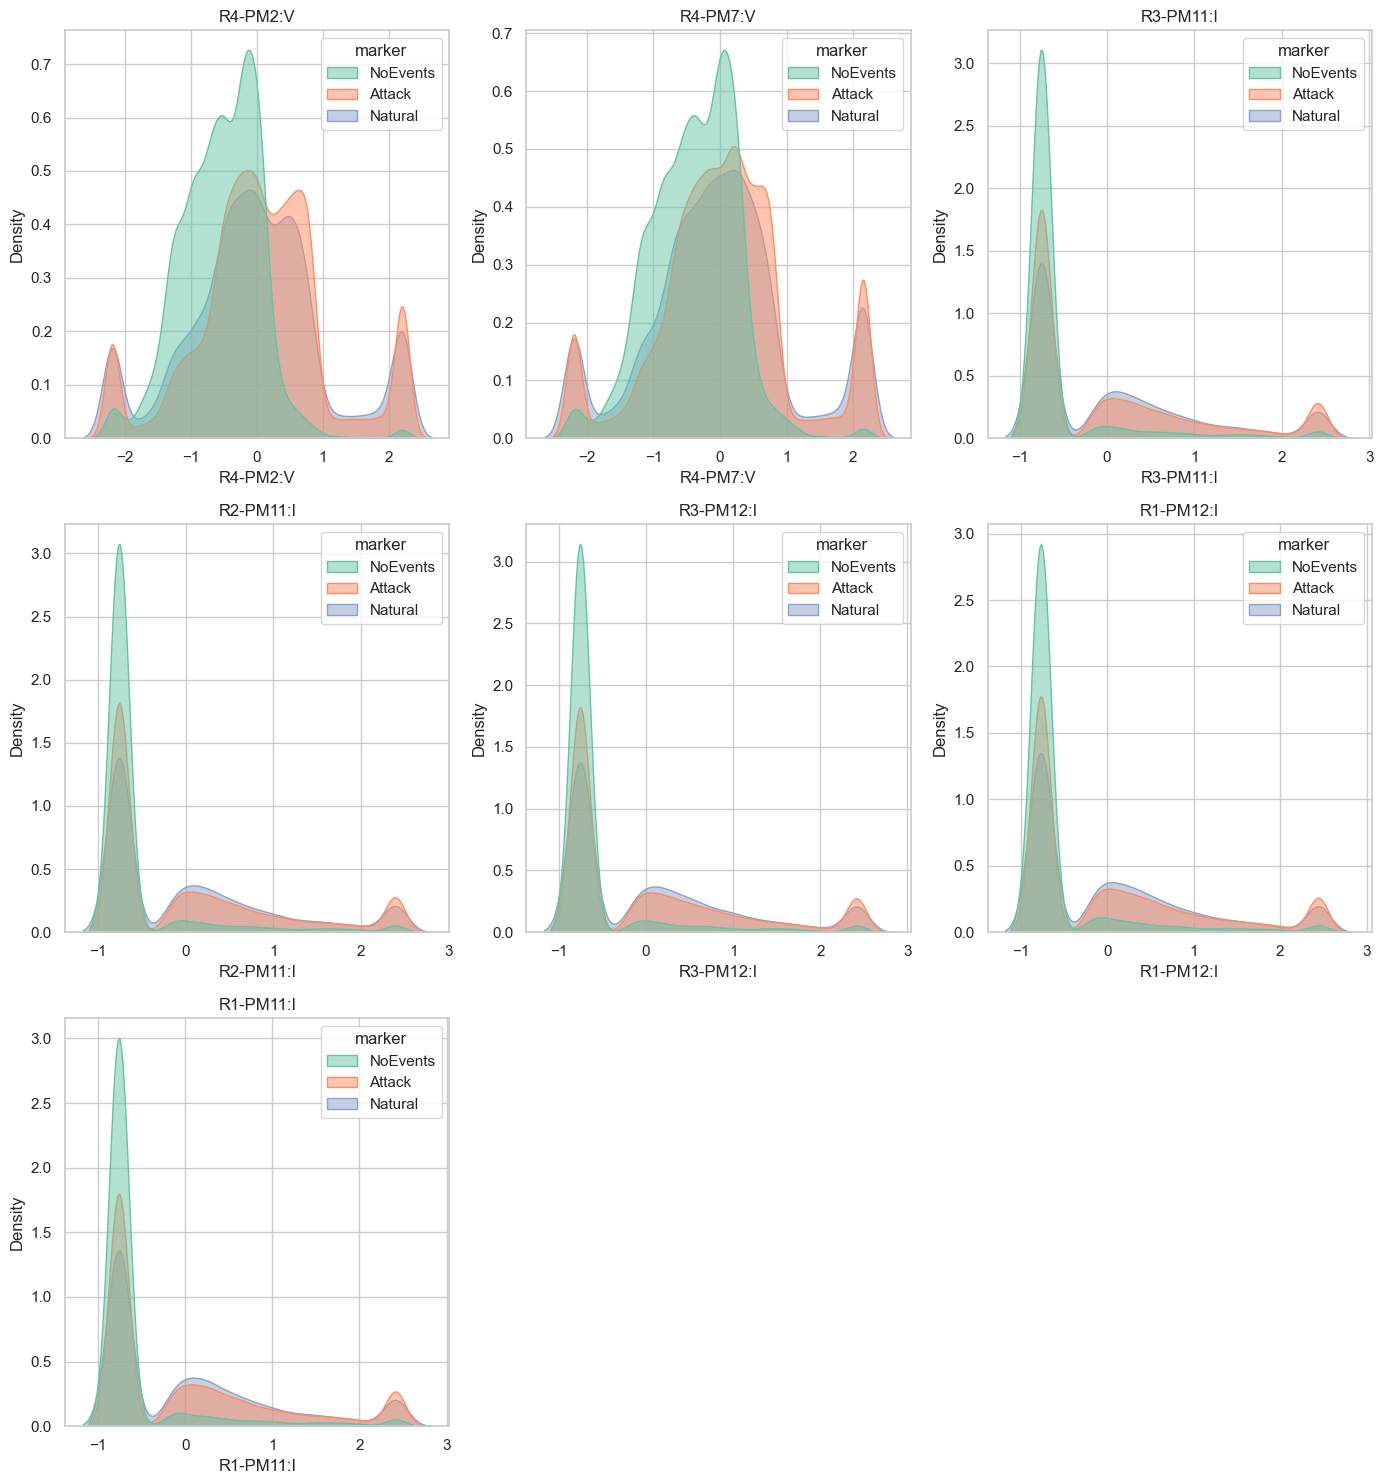

In [161]:
# ============================================================
# Load CLEAN three-class dataset
# ============================================================

three_df = pd.read_csv("../data/merged/three_class_dataset_clean_FULL.csv")

three_df.columns = three_df.columns.str.strip()

target_col = "marker"

print("Dataset shape:", three_df.shape)


# ============================================================
# Encode target
# ============================================================

three_df["target_num"] = three_df[target_col].astype("category").cat.codes


# ============================================================
# Select numeric features
# ============================================================

numeric_cols = three_df.select_dtypes(include="number").columns

numeric_cols = [
    c for c in numeric_cols
    if c not in ["target_num", "marker", "Scenario_ID"]
    and "log" not in c.lower()
]


# ============================================================
# Correlation with target
# ============================================================

corr_target = (
    three_df[numeric_cols]
    .corrwith(three_df["target_num"])
    .abs()
    .sort_values(ascending=False)
)



# ============================================================
# Top features
# ============================================================

top10_features = corr_target.head(10).index.tolist()

print("\nTop 10 features:")
print(top10_features)

top7_three = corr_target.head(7)
print("Top 7 Three-Class Features used for plots:")
print(top7_three)

top7_three.to_json(
    "../data/features/three_top_features.json",
    indent=4
)


# ============================================================
# Top 10 Feature Bar Plot
# ============================================================

plt.figure(figsize=(12,6))

top10_features = corr_target.head(10)

ax = sns.barplot(
    x=top10_features.index,
    y=top10_features.values,
    color="#4C72B0"
)

# Add correlation values on bars
for i, v in enumerate(top10_features.values):
    ax.text(
        i,
        v + 0.001,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Features Correlated with Target (Three-Class)")
plt.ylabel("Absolute Correlation")
plt.xlabel("Feature")

plt.tight_layout()

plt.show()


# ============================================================
# Scale features for visualization
# ============================================================

from sklearn.preprocessing import StandardScaler

viz_df = three_df.copy()

scaler = StandardScaler()

viz_df[top_features] = scaler.fit_transform(viz_df[top_features])


# ============================================================
# Violin + Boxplots
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(top_features)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,5*n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_features):

    sns.violinplot(
        x=target_col,
        y=feat,
        data=viz_df,
        inner=None,
        palette="Set2",
        ax=axes[i]
    )

    sns.boxplot(
        x=target_col,
        y=feat,
        data=viz_df,
        width=0.25,
        showfliers=False,
        boxprops={'facecolor':'white','edgecolor':'black','linewidth':1.2},
        medianprops={'color':'red','linewidth':2},
        ax=axes[i]
    )

    axes[i].set_title(f"{feat} vs {target_col}")

for j in range(len(top_features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Three-Class Feature Distributions", fontsize=18)

plt.tight_layout()
plt.show()


# ============================================================
# Pairplot (sampled)
# ============================================================

sample_df = viz_df.sample(
    n=min(3000, len(viz_df)),
    random_state=42
)

sns.pairplot(
    sample_df[top_features + [target_col]],
    hue=target_col,
    palette="Set2",
    diag_kind="kde"
)

plt.suptitle("Three-Class Pairplot", y=1.02)

plt.show()


# ============================================================
# KDE plots
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(top_features)/n_cols))

plt.figure(figsize=(14,5*n_rows))

for i, feature in enumerate(top_features):

    plt.subplot(n_rows, n_cols, i+1)

    sns.kdeplot(
        data=viz_df,
        x=feature,
        hue=target_col,
        fill=True,
        common_norm=False,
        palette="Set2",
        alpha=0.5
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

In [122]:
# --------------------------------------------
# 1. Load dataset & basic description
# --------------------------------------------
multi_df_raw = pd.read_csv("../data/merged/multi_class_dataset.csv")
multi_df_raw.columns = multi_df_raw.columns.str.strip()
print("===== Multi-Class Dataset Loaded =====")
print(f"Rows: {multi_df_raw.shape[0]:,}")
print(f"Columns: {multi_df_raw.shape[1]}")
print("\n===== Column Names =====")
print(list(multi_df_raw.columns))
print("\n===== Info =====")
print(multi_df_raw.info())
print("\n===== First 5 rows =====")
display(multi_df_raw.head())
print("\n===== Missing values per column =====")
print(multi_df_raw.isna().sum())

print(
    "\nTotal INF:",
    np.isinf(
        multi_df_raw.select_dtypes(include=np.number)
    ).sum().sum()
)
print("\n===== Summary statistics (first 10 numeric cols) =====")
display(multi_df_raw.select_dtypes(include='number').iloc[:, :10].describe().T)

===== Multi-Class Dataset Loaded =====
Rows: 78,377
Columns: 129

===== Column Names =====
['R1-PA1:VH', 'R1-PM1:V', 'R1-PA2:VH', 'R1-PM2:V', 'R1-PA3:VH', 'R1-PM3:V', 'R1-PA4:IH', 'R1-PM4:I', 'R1-PA5:IH', 'R1-PM5:I', 'R1-PA6:IH', 'R1-PM6:I', 'R1-PA7:VH', 'R1-PM7:V', 'R1-PA8:VH', 'R1-PM8:V', 'R1-PA9:VH', 'R1-PM9:V', 'R1-PA10:IH', 'R1-PM10:I', 'R1-PA11:IH', 'R1-PM11:I', 'R1-PA12:IH', 'R1-PM12:I', 'R1:F', 'R1:DF', 'R1-PA:Z', 'R1-PA:ZH', 'R1:S', 'R2-PA1:VH', 'R2-PM1:V', 'R2-PA2:VH', 'R2-PM2:V', 'R2-PA3:VH', 'R2-PM3:V', 'R2-PA4:IH', 'R2-PM4:I', 'R2-PA5:IH', 'R2-PM5:I', 'R2-PA6:IH', 'R2-PM6:I', 'R2-PA7:VH', 'R2-PM7:V', 'R2-PA8:VH', 'R2-PM8:V', 'R2-PA9:VH', 'R2-PM9:V', 'R2-PA10:IH', 'R2-PM10:I', 'R2-PA11:IH', 'R2-PM11:I', 'R2-PA12:IH', 'R2-PM12:I', 'R2:F', 'R2:DF', 'R2-PA:Z', 'R2-PA:ZH', 'R2:S', 'R3-PA1:VH', 'R3-PM1:V', 'R3-PA2:VH', 'R3-PM2:V', 'R3-PA3:VH', 'R3-PM3:V', 'R3-PA4:IH', 'R3-PM4:I', 'R3-PA5:IH', 'R3-PM5:I', 'R3-PA6:IH', 'R3-PM6:I', 'R3-PA7:VH', 'R3-PM7:V', 'R3-PA8:VH', 'R3-PM8:V', 

,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH,R1-PM3:V,R1-PA4:IH,R1-PM4:I,R1-PA5:IH,R1-PM5:I,...,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4,marker
0,66.445916,133715.7489,-53.537176,133715.7489,-173.531727,133790.9687,63.896253,589.79731,-60.464236,622.57400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41
1,59.908467,127622.9443,-60.068895,127597.8710,179.943125,127673.0908,55.089892,629.34907,-67.964254,654.06892,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41
2,58.630771,127296.9918,-61.346591,127271.9185,178.659700,127372.2116,52.987137,638.68768,-69.494051,658.09734,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41
3,62.996710,131534.3744,-56.980653,131509.3012,-176.969474,131609.5942,62.068518,448.25328,-61.237729,466.38117,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41
4,64.314513,131333.7883,-55.680039,131308.7150,-175.668860,131434.0813,62.979521,451.54926,-59.616259,466.38117,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41



===== Missing values per column =====
R1-PA1:VH     0
R1-PM1:V      0
R1-PA2:VH     0
R1-PM2:V      0
R1-PA3:VH     0
             ..
snort_log1    0
snort_log2    0
snort_log3    0
snort_log4    0
marker        0
Length: 129, dtype: int64

Total INF: 10906

===== Summary statistics (first 10 numeric cols) =====


,count,mean,std,min,25%,50%,75%,max
R1-PA1:VH,78377.0,-15.802424,100.876750,-179.988962,-100.416583,-28.865614,68.096034,179.994691
R1-PM1:V,78377.0,130764.039577,8546.118477,0.000000,131057.982300,131684.814000,132186.279400,151592.990400
R1-PA2:VH,78377.0,2.175196,111.743169,-179.994691,-102.129727,8.118812,104.897113,179.994691
R1-PM2:V,78377.0,131035.528095,5393.135370,0.000000,130732.029800,131358.861500,131885.400200,151567.917200
R1-PA3:VH,78377.0,6.834315,97.065063,-179.994691,-69.459674,13.401483,85.324875,179.988962
R1-PM3:V,78377.0,131395.717581,5443.752388,0.000000,131133.202100,131760.033900,132261.499300,151693.283500
R1-PA4:IH,78377.0,-14.334996,99.601107,-179.994691,-98.159129,-23.514188,66.274028,179.994691
R1-PM4:I,78377.0,393.949321,190.966011,0.000000,305.793700,378.671480,456.676340,1779.462980
R1-PA5:IH,78377.0,3.538540,109.504977,-179.994691,-94.790138,1.885031,102.674037,179.994691
R1-PM5:I,78377.0,387.438133,151.277183,0.000000,311.836330,383.249230,460.338540,1265.656320


=== Class Distribution (3 Groups) ===
target_3class
Attack     55663
Natural    18309
NoEvent     4405
Name: count, dtype: int64

Proportion (%):
target_3class
Attack     71.02
Natural    23.36
NoEvent     5.62
Name: proportion, dtype: float64


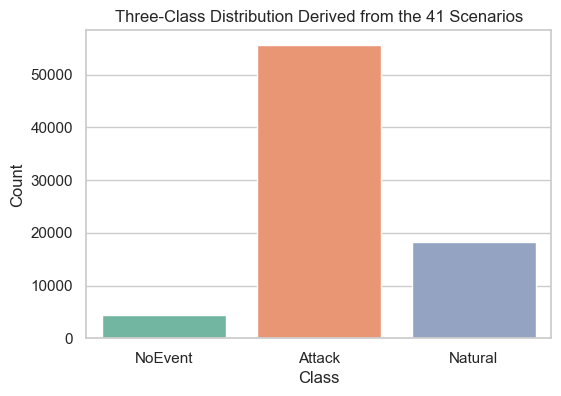

In [123]:
# Create new 3-class target
multi_df_raw["target_3class"] = "Unknown"
# Natural scenarios
natural = list(range(1, 7)) + [13, 14]
# No event scenario
noevent = [41]
# Attack scenarios = everything else 7–12, 15–20, 21–30, 35–40
attack = [s for s in multi_df_raw["marker"].unique() if s not in natural + noevent]
# Assign classes
multi_df_raw.loc[multi_df["marker"].isin(natural), "target_3class"] = "Natural"
multi_df_raw.loc[multi_df["marker"].isin(noevent), "target_3class"] = "NoEvent"
multi_df_raw.loc[multi_df["marker"].isin(attack), "target_3class"] = "Attack"
print("=== Class Distribution (3 Groups) ===")
print(multi_df_raw["target_3class"].value_counts())
print("\nProportion (%):")
print((multi_df_raw["target_3class"].value_counts(normalize=True) * 100).round(2))
# -----------------------------
# Plot Class Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="target_3class", data=multi_df_raw, palette="Set2")
plt.title("Three-Class Distribution Derived from the 41 Scenarios")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


===== Scenario Group Distribution =====
scenario_group
Relay Setting Change Attack      37344
Short-Circuit Fault (Natural)    15000
Data Injection Attack             9582
Remote Tripping Attack            8737
No Event (Normal Operation)       4405
Line Maintenance (Natural)        3309
Name: count, dtype: int64

===== Percentage Distribution =====
scenario_group
Relay Setting Change Attack      47.65
Short-Circuit Fault (Natural)    19.14
Data Injection Attack            12.23
Remote Tripping Attack           11.15
No Event (Normal Operation)       5.62
Line Maintenance (Natural)        4.22
Name: count, dtype: float64


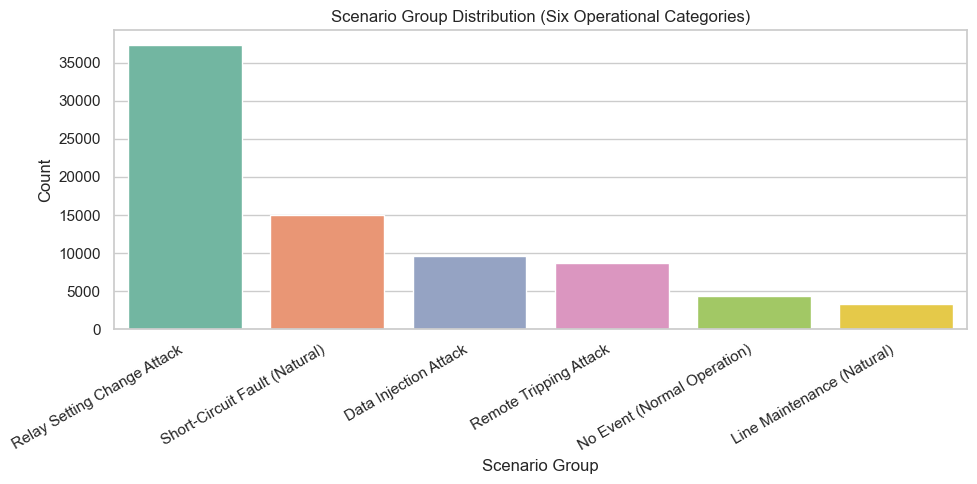

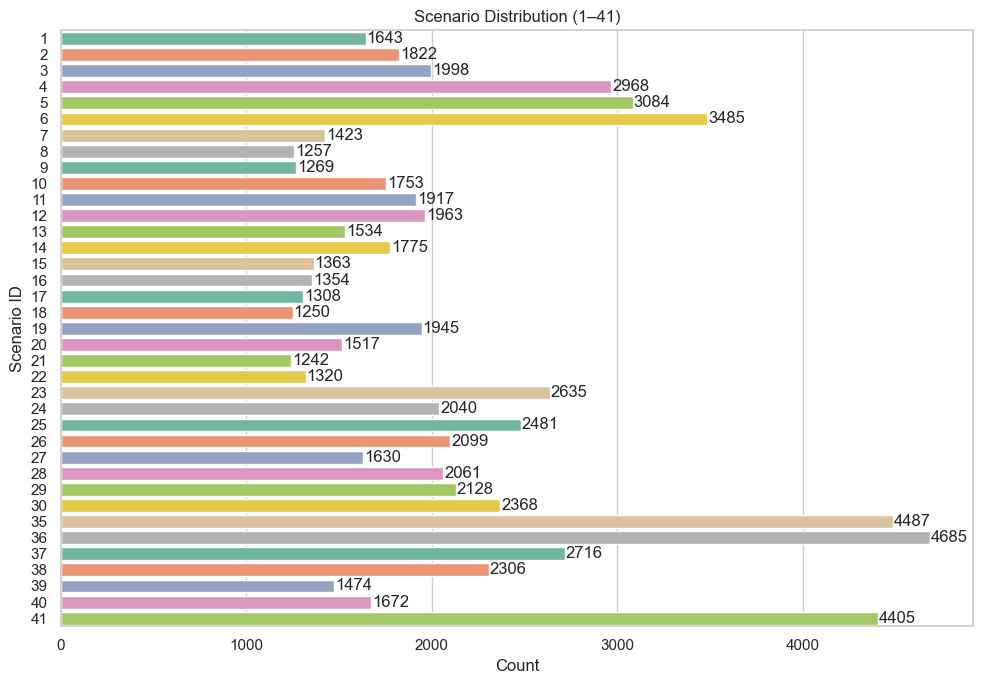

In [173]:
# -------------------------------------------------
# 3. Group the 41 scenarios into 6 high-level types
# -------------------------------------------------

# Mapping scenarios → six operational categories
def map_six_groups(s):
    s = int(s)
    if 1 <= s <= 6:
        return "Short-Circuit Fault (Natural)"
    elif 7 <= s <= 12:
        return "Data Injection Attack"
    elif 13 <= s <= 14:
        return "Line Maintenance (Natural)"
    elif 15 <= s <= 20:
        return "Remote Tripping Attack"
    elif 21 <= s <= 30 or 35 <= s <= 40:
        return "Relay Setting Change Attack"
    elif s == 41:
        return "No Event (Normal Operation)"
    else:
        return "Unknown"

# Apply mapping
multi_df_raw["scenario_group"] = multi_df_raw["marker"].apply(map_six_groups)

# Summary
print("\n===== Scenario Group Distribution =====")
counts = multi_df_raw["scenario_group"].value_counts()
print(counts)
print("\n===== Percentage Distribution =====")
print((counts / counts.sum() * 100).round(2))

# Plot
plt.figure(figsize=(10,5))
sns.countplot(
    data=multi_df_raw,
    x="scenario_group",
    order=counts.index,
    palette="Set2"
)
plt.xticks(rotation=30, ha='right')
plt.title("Scenario Group Distribution (Six Operational Categories)")
plt.xlabel("Scenario Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 5. Raw scenario distribution (1–41)
# --------------------------------------------
scenario_counts = multi_df_raw["marker"].value_counts().sort_index()

plt.figure(figsize=(10,7))

ax = sns.barplot(
    y=scenario_counts.index,
    x=scenario_counts.values,
    palette="Set2",
    orient="h"
)

# Add value labels on bars
for i, v in enumerate(scenario_counts.values):
    ax.text(v + 5, i, str(v), va="center")

plt.title("Scenario Distribution (1–41)")
plt.xlabel("Count")
plt.ylabel("Scenario ID")

plt.tight_layout()
plt.show()



,Scenario,control_panel_log1,control_panel_log2,control_panel_log3,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4
marker,,,,,,,,,,,,,
1,Fault L1 (10–19%),0,0,0,0,216,239,0,0,0,0,0,0
2,Fault L1 (20–79%),0,0,0,0,238,240,0,0,0,0,0,0
3,Fault L1 (80–90%),0,0,0,0,248,257,0,0,0,0,0,0
4,Fault L2 (10–19%),0,0,0,0,0,0,234,250,0,0,0,0
5,Fault L2 (20–79%),0,0,0,0,0,0,253,255,0,0,0,0
6,Fault L2 (80–90%),0,0,0,0,0,0,263,275,0,0,0,0
7,Data Injection: L1 Fault 10–19% with tripping,0,0,0,0,161,161,0,0,0,0,0,0
8,Data Injection: L1 Fault 20–79% with tripping,0,0,0,0,160,160,0,0,0,0,0,0
9,Data Injection: L1 Fault 80–90% with tripping,0,0,0,0,149,149,0,0,1,1,0,0


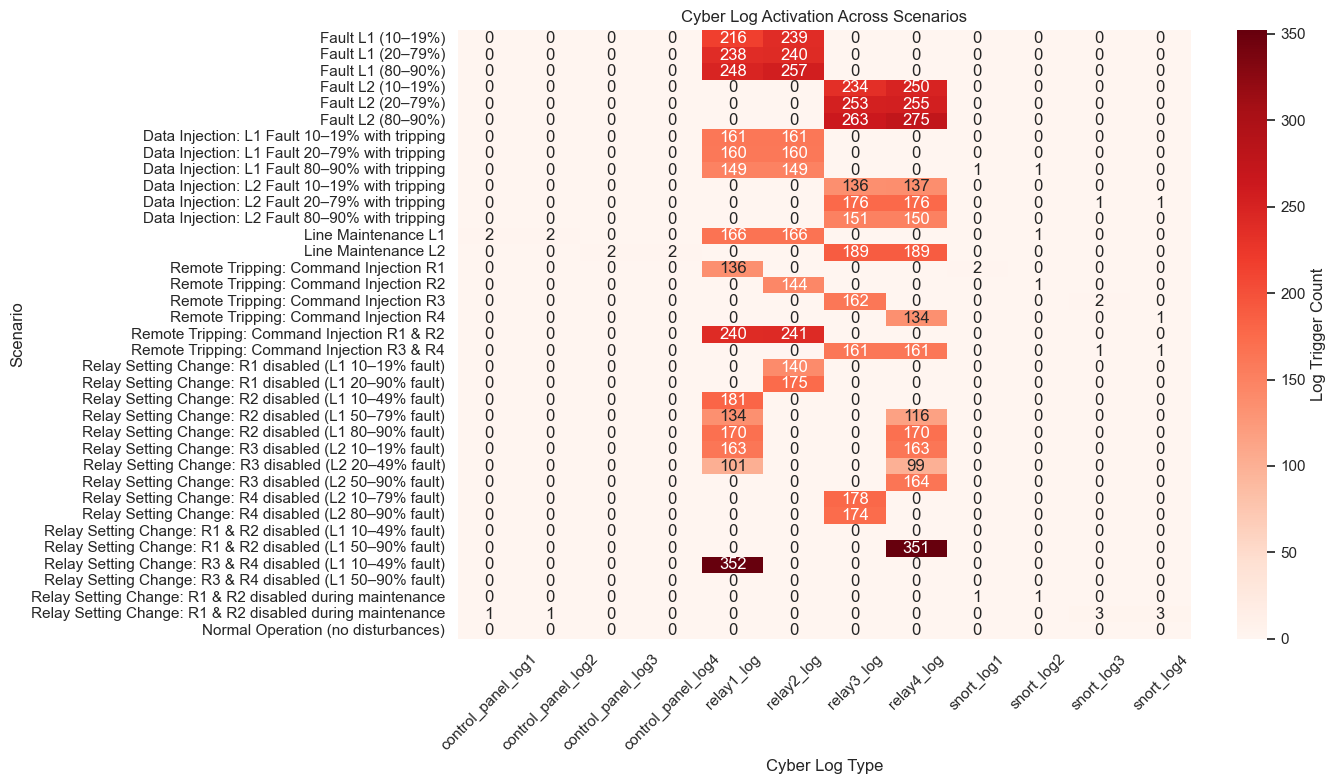

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

log_cols = [
    "control_panel_log1","control_panel_log2","control_panel_log3","control_panel_log4",
    "relay1_log","relay2_log","relay3_log","relay4_log",
    "snort_log1","snort_log2","snort_log3","snort_log4"
]

scenario_logs = multi_df.groupby("marker")[log_cols].sum()

# convert to integer
scenario_logs = scenario_logs.astype(int)

# add scenario names
scenario_logs["Scenario"] = scenario_logs.index.map(SCENARIO_LOOKUP)

# reorder columns
scenario_logs = scenario_logs[
    ["Scenario"] + log_cols
]

# sort by marker
scenario_logs = scenario_logs.sort_index()

display(scenario_logs)

heatmap_data = multi_df.groupby("marker")[log_cols].sum()

heatmap_data.index = heatmap_data.index.map(SCENARIO_LOOKUP)

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    cbar_kws={"label": "Log Trigger Count"}
)

plt.xlabel("Cyber Log Type")
plt.ylabel("Scenario")
plt.title("Cyber Log Activation Across Scenarios")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [186]:
for r, cols in relay_groups.items():
    print(r, len(cols))

    df_scaled.groupby("marker")[relay_groups["R3"]].mean().head()

R1 30
R2 30
R3 30
R4 30


Cyber Log Presence by Scenario


,Scenario,total_samples,samples_with_logs,percentage_with_logs
marker,,,,
1,Fault L1 (10–19%),1643,274,16.676811
2,Fault L1 (20–79%),1822,246,13.501647
3,Fault L1 (80–90%),1998,294,14.714715
4,Fault L2 (10–19%),2968,294,9.905660
5,Fault L2 (20–79%),3084,261,8.463035
6,Fault L2 (80–90%),3485,318,9.124821
7,Data Injection: L1 Fault 10–19% with tripping,1423,161,11.314125
8,Data Injection: L1 Fault 20–79% with tripping,1257,160,12.728719
9,Data Injection: L1 Fault 80–90% with tripping,1269,151,11.899133


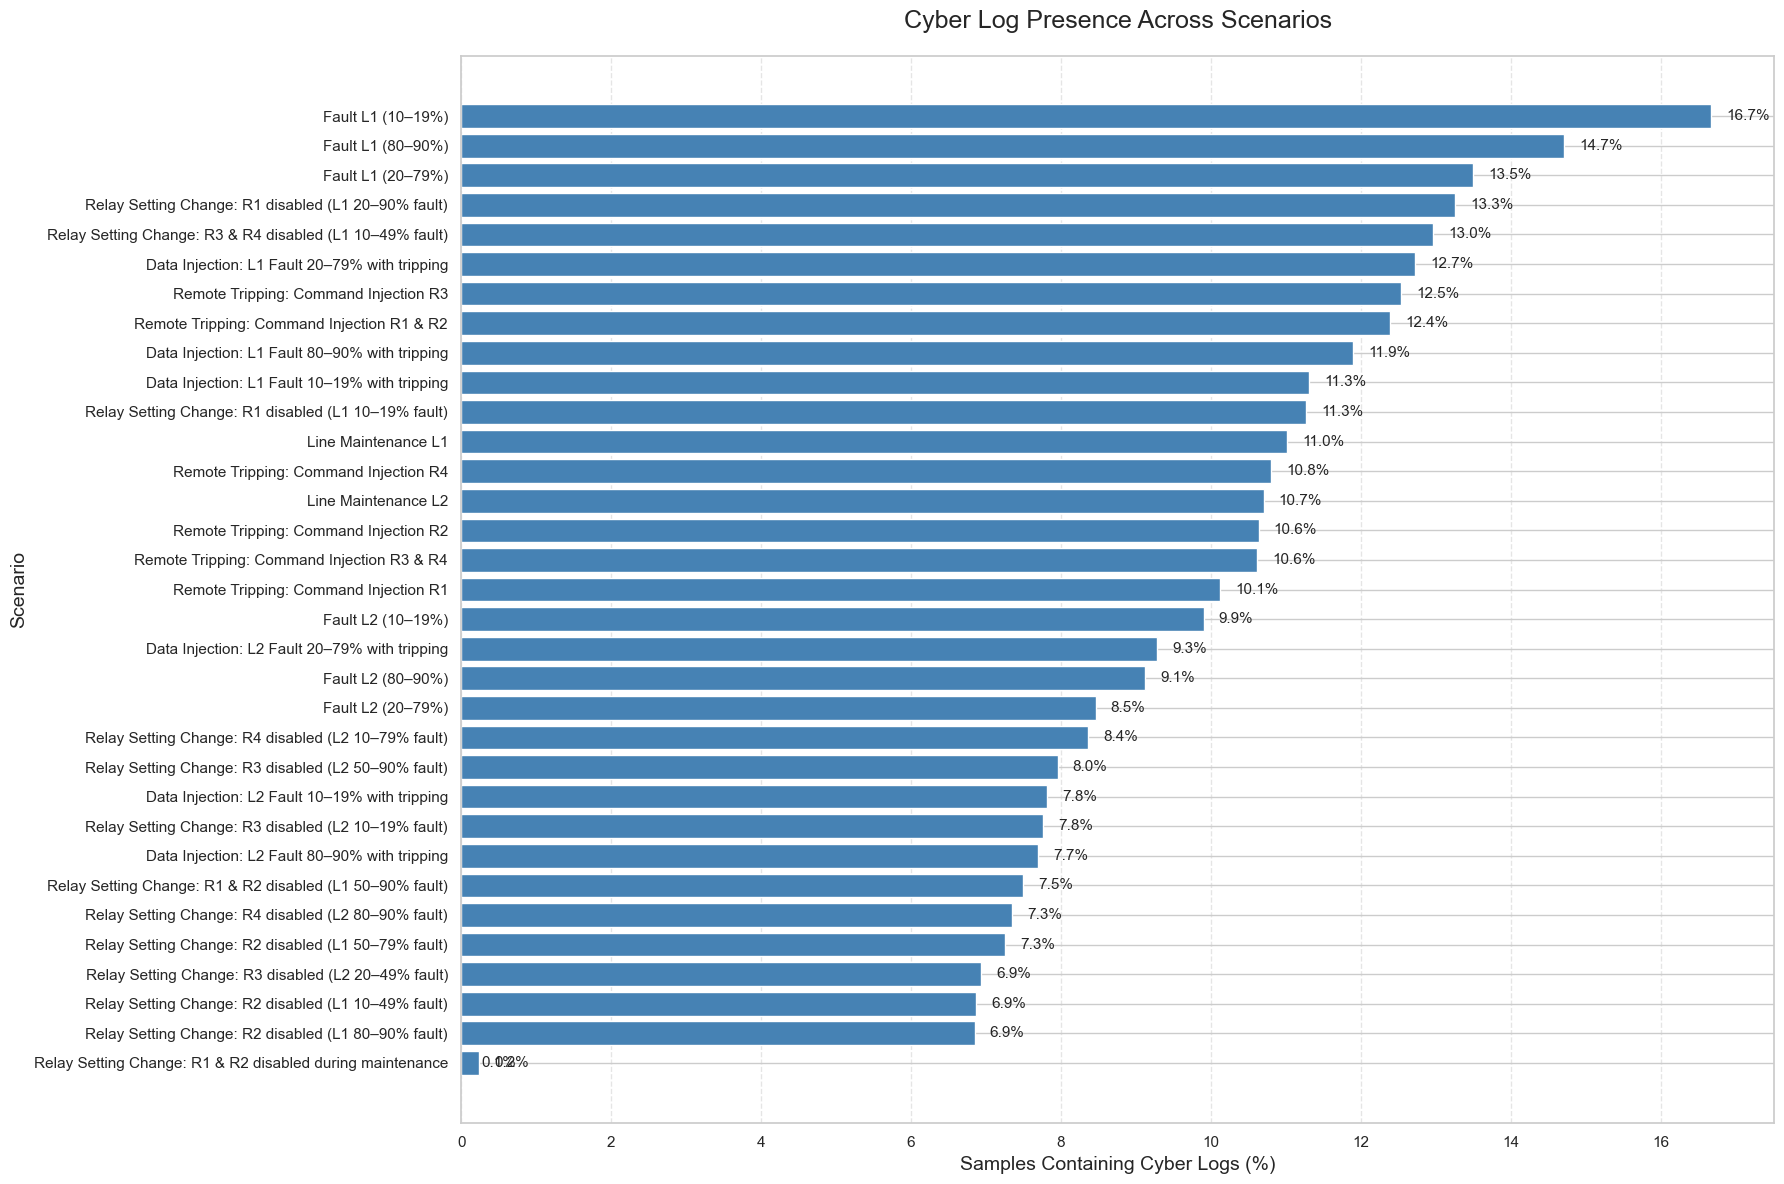

In [179]:
# ============================================================
# Cyber Log Presence by Scenario
# ============================================================

log_cols = [
    "control_panel_log1","control_panel_log2","control_panel_log3","control_panel_log4",
    "relay1_log","relay2_log","relay3_log","relay4_log",
    "snort_log1","snort_log2","snort_log3","snort_log4"
]

# ------------------------------------------------------------
# Flag samples that contain ANY cyber log
# ------------------------------------------------------------
multi_df["has_log"] = (multi_df[log_cols].sum(axis=1) > 0).astype(int)

# ------------------------------------------------------------
# Scenario-level statistics
# ------------------------------------------------------------
scenario_log_summary = multi_df.groupby("marker").agg(
    total_samples=("has_log","count"),
    samples_with_logs=("has_log","sum")
)

scenario_log_summary["percentage_with_logs"] = (
    scenario_log_summary["samples_with_logs"] /
    scenario_log_summary["total_samples"]
) * 100

# Add scenario names
scenario_log_summary["Scenario"] = scenario_log_summary.index.map(SCENARIO_LOOKUP)

# Reorder columns
scenario_log_summary = scenario_log_summary[
    ["Scenario","total_samples","samples_with_logs","percentage_with_logs"]
]

print("Cyber Log Presence by Scenario")
display(scenario_log_summary.sort_index())

plot_df = scenario_log_summary.copy()

# remove scenarios with 0%
plot_df = plot_df[plot_df["percentage_with_logs"] > 0]

# sort
plot_df = plot_df.sort_values("percentage_with_logs")

fig, ax = plt.subplots(figsize=(18,12))

bars = ax.barh(
    plot_df["Scenario"],
    plot_df["percentage_with_logs"],
    color="steelblue"
)

# add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=11
    )

ax.set_xlabel("Samples Containing Cyber Logs (%)", fontsize=14)
ax.set_ylabel("Scenario", fontsize=14)

ax.set_title(
    "Cyber Log Presence Across Scenarios",
    fontsize=18,
    pad=20
)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [187]:
for r, cols in relay_groups.items():
    print(r)
    print(
        df.groupby("marker")[cols]
        .mean()
        .abs()
        .max(axis=1)
        .head(6)
    )

R1
marker
1    131929.434865
2    131841.109153
3    131825.534337
4    131660.940369
5    131571.195709
6    131679.936091
dtype: float64
R2
marker
1    129815.096918
2    129849.327262
3    129845.377132
4    129617.126733
5    129490.882598
6    129620.593243
dtype: float64
R3
marker
1    129356.357296
2    129386.660331
3    129379.993243
4    129614.740216
5    129486.797222
6    129585.069785
dtype: float64
R4
marker
1    131638.038957
2    131608.666022
3    131617.638802
4    132322.017459
5    132210.372042
6    132258.433128
dtype: float64


PMU measurement signals: 60


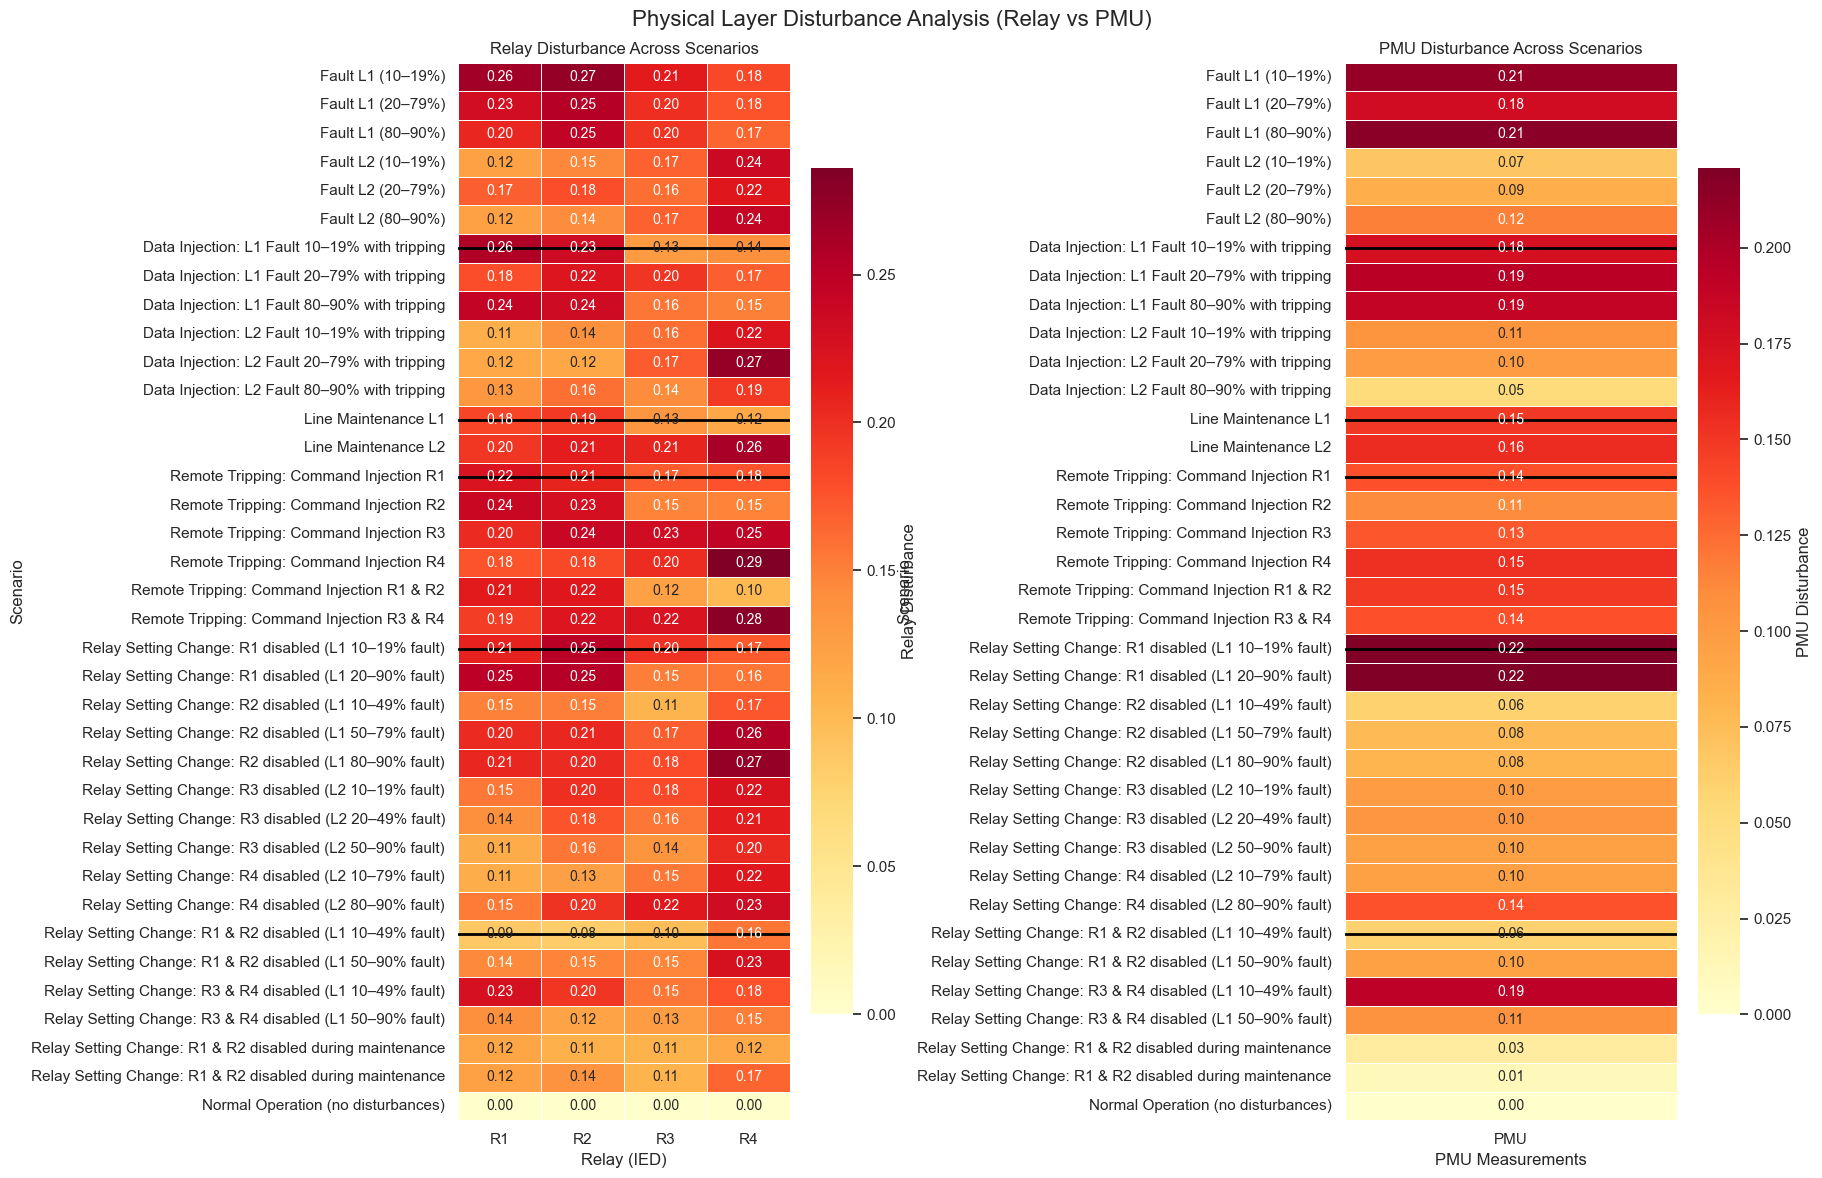

In [191]:
# ============================================================
# Physical Layer Disturbance Analysis (Relay vs PMU)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/merged/multi_class_dataset_clean_FULL.csv")

# ------------------------------------------------------------
# 1. Relay Features
# ------------------------------------------------------------
relay_groups = {
    "R1": [c for c in df.columns if c.startswith("R1") and ":" in c],
    "R2": [c for c in df.columns if c.startswith("R2") and ":" in c],
    "R3": [c for c in df.columns if c.startswith("R3") and ":" in c],
    "R4": [c for c in df.columns if c.startswith("R4") and ":" in c],
}

all_relay_features = sum(relay_groups.values(), [])

# ------------------------------------------------------------
# 2. PMU Measurement Features (Only measurement suffixes)
# ------------------------------------------------------------
pmu_cols = [
    c for c in df.columns
    if any(c.endswith(s) for s in [":V", ":I", ":Z", ":F", ":DF"])
]

print("PMU measurement signals:", len(pmu_cols))

# ------------------------------------------------------------
# 3. Standardize Signals
# ------------------------------------------------------------
scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[all_relay_features + pmu_cols] = scaler.fit_transform(
    df[all_relay_features + pmu_cols]
)

# ------------------------------------------------------------
# 4. Relay Disturbance
# ------------------------------------------------------------
relay_scenario = {}

for r, cols in relay_groups.items():

    relay_mean = df_scaled.groupby("marker")[cols].mean()

    baseline = relay_mean.loc[41]
    
    relay_scenario[r] = (
        (relay_mean - baseline)
        .abs()
        .mean(axis=1)
    )

relay_disturbance = pd.DataFrame(relay_scenario).sort_index()

# ------------------------------------------------------------
# 5. PMU Disturbance
# ------------------------------------------------------------
pmu_signal = df_scaled[pmu_cols].abs().mean(axis=1)

pmu_df = pmu_signal.groupby(df_scaled["marker"]).mean().to_frame("PMU")

baseline_pmu = pmu_df.loc[41]

pmu_disturbance = abs(pmu_df - baseline_pmu)

# ------------------------------------------------------------
# 6. Plot Heatmaps
# ------------------------------------------------------------

fig, axes = plt.subplots(1,2, figsize=(18,12))

# Separate color scales
relay_vmax = relay_disturbance.values.max()
pmu_vmax = pmu_disturbance.values.max()
relay_disturbance.index = relay_disturbance.index.map(SCENARIO_LOOKUP)
pmu_disturbance.index = pmu_disturbance.index.map(SCENARIO_LOOKUP)

# ------------------------------------------------------------
# Relay Heatmap
# ------------------------------------------------------------
sns.heatmap(
    relay_disturbance,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":10},
    vmin=0,
    vmax=relay_vmax,
    ax=axes[0],
    cbar_kws={"label":"Relay Disturbance", "shrink":0.8}
)

axes[0].set_title("Relay Disturbance Across Scenarios")
axes[0].set_xlabel("Relay (IED)")
axes[0].set_ylabel("Scenario")

# ------------------------------------------------------------
# PMU Heatmap
# ------------------------------------------------------------
sns.heatmap(
    pmu_disturbance,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":10},
    vmin=0,
    vmax=pmu_vmax,
    ax=axes[1],
    cbar_kws={"label":"PMU Disturbance", "shrink":0.8}
)

axes[1].set_title("PMU Disturbance Across Scenarios")
axes[1].set_xlabel("PMU Measurements")
axes[1].set_ylabel("Scenario")

# ------------------------------------------------------------
# Scenario group separators
# ------------------------------------------------------------
for y in [6,12,14,20,30,40]:
    axes[0].axhline(y + 0.5, color="black", linewidth=2)
    axes[1].axhline(y + 0.5, color="black", linewidth=2)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------
plt.suptitle("Physical Layer Disturbance Analysis (Relay vs PMU)", fontsize=16)

plt.tight_layout()
plt.show()

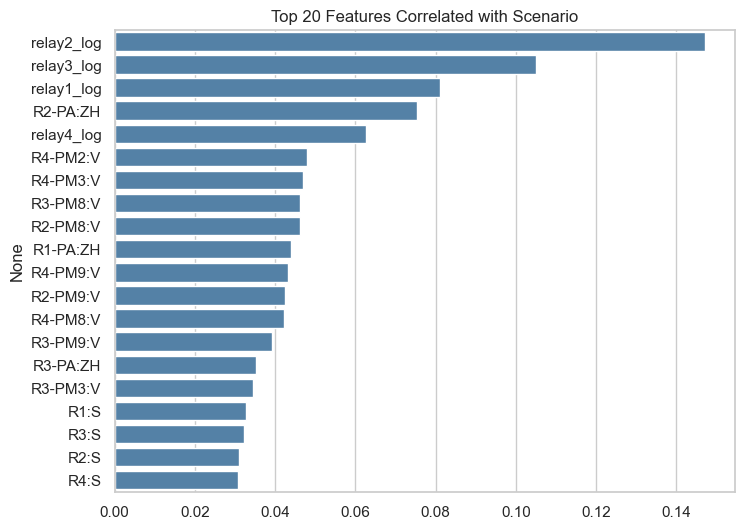

Top 15 Multi-Class Features:
relay2_log    0.147121
relay3_log    0.105007
relay1_log    0.080983
R2-PA:ZH      0.075258
relay4_log    0.062590
R4-PM2:V      0.048018
R4-PM3:V      0.046870
R3-PM8:V      0.046290
R2-PM8:V      0.046249
R1-PA:ZH      0.044100
R4-PM9:V      0.043340
R2-PM9:V      0.042483
R4-PM8:V      0.042322
R3-PM9:V      0.039183
R3-PA:ZH      0.035276
dtype: float64


In [171]:
# Top features correlated with scenario
num_feats = multi_df_raw.select_dtypes(include=np.number).drop(columns="marker")

target = multi_df_raw["marker"]

abs_corr = num_feats.apply(lambda x: x.corr(target)).abs()

top20 = abs_corr.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top20.values,
    y=top20.index,
    color="steelblue"
)

plt.title("Top 20 Features Correlated with Scenario")

plt.show()

top15_multi = top20.head(15)

print("Top 15 Multi-Class Features:")
print(top15_multi)

top15_multi.to_json(
    "../data/features/multi_top_features.json",
    indent=4
)

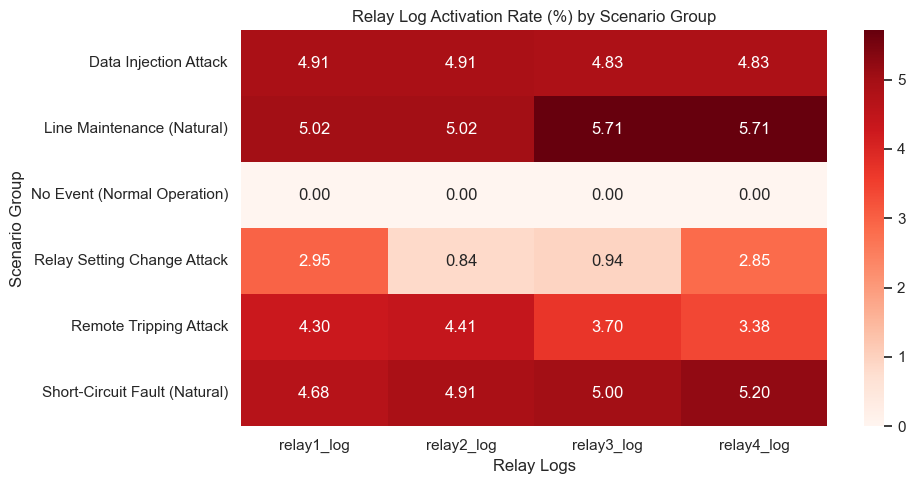

In [168]:
log_cols = [
    "relay1_log","relay2_log","relay3_log","relay4_log"
]

log_rate = (
    multi_df_raw
    .groupby("scenario_group")[log_cols]
    .mean() * 100
)

plt.figure(figsize=(10,5))

sns.heatmap(
    log_rate,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Relay Log Activation Rate (%) by Scenario Group")

plt.ylabel("Scenario Group")
plt.xlabel("Relay Logs")

plt.tight_layout()
plt.show()

In [172]:
# ============================================================
# Full Relay Disturbance Heatmap (All Relay Measurements)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = multi_df.copy()

# ------------------------------------------------------------
# 1. Identify relay feature groups
# ------------------------------------------------------------
relay_groups = {
    "R1": [c for c in df.columns if c.startswith("R1")],
    "R2": [c for c in df.columns if c.startswith("R2")],
    "R3": [c for c in df.columns if c.startswith("R3")],
    "R4": [c for c in df.columns if c.startswith("R4")]
}

all_relay_features = sum(relay_groups.values(), [])

# ------------------------------------------------------------
# 2. Standardize relay signals
# ------------------------------------------------------------
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[all_relay_features] = scaler.fit_transform(df[all_relay_features])

# ------------------------------------------------------------
# 3. Average relay behaviour per scenario
# ------------------------------------------------------------
relay_scenario = {}

for r, cols in relay_groups.items():
    relay_scenario[r] = df_scaled.groupby("marker")[cols].mean().abs().max(axis=1)

relay_scenario_df = pd.DataFrame(relay_scenario).sort_index()

# ------------------------------------------------------------
# 4. Disturbance relative to normal operation
# ------------------------------------------------------------
baseline = relay_scenario_df.loc[41]

disturbance = abs(relay_scenario_df - baseline)

# ------------------------------------------------------------
# 5. Plot heatmap
# ------------------------------------------------------------
plt.figure(figsize=(10,12))

ax = sns.heatmap(
    disturbance,
    cmap="Reds",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label":"Relay Disturbance (Standardized Units)"}
)

# Scenario group separators
for y in [6,12,14,20,30,40]:
    ax.hlines(y+0.5, *ax.get_xlim(), colors="black", linewidth=2)

plt.title("Full Relay Disturbance Across 41 Grid Scenarios")

plt.xlabel("Relay (IED)")
plt.ylabel("Scenario ID")

plt.tight_layout()
plt.show()

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [52]:
print(relay_groups)

{'R1': ['R1-PA1:VH', 'R1-PM1:V', 'R1-PA2:VH', 'R1-PM2:V', 'R1-PA3:VH', 'R1-PM3:V', 'R1-PA4:IH', 'R1-PM4:I', 'R1-PA5:IH', 'R1-PM5:I', 'R1-PA6:IH', 'R1-PM6:I', 'R1-PA7:VH', 'R1-PM7:V', 'R1-PA8:VH', 'R1-PM8:V', 'R1-PA9:VH', 'R1-PM9:V', 'R1-PA10:IH', 'R1-PM10:I', 'R1-PA11:IH', 'R1-PM11:I', 'R1-PA12:IH', 'R1-PM12:I', 'R1:F', 'R1:DF', 'R1-PA:Z', 'R1-PA:ZH', 'R1:S'], 'R2': ['R2-PA1:VH', 'R2-PM1:V', 'R2-PA2:VH', 'R2-PM2:V', 'R2-PA3:VH', 'R2-PM3:V', 'R2-PA4:IH', 'R2-PM4:I', 'R2-PA5:IH', 'R2-PM5:I', 'R2-PA6:IH', 'R2-PM6:I', 'R2-PA7:VH', 'R2-PM7:V', 'R2-PA8:VH', 'R2-PM8:V', 'R2-PA9:VH', 'R2-PM9:V', 'R2-PA10:IH', 'R2-PM10:I', 'R2-PA11:IH', 'R2-PM11:I', 'R2-PA12:IH', 'R2-PM12:I', 'R2:F', 'R2:DF', 'R2-PA:Z', 'R2-PA:ZH', 'R2:S'], 'R3': ['R3-PA1:VH', 'R3-PM1:V', 'R3-PA2:VH', 'R3-PM2:V', 'R3-PA3:VH', 'R3-PM3:V', 'R3-PA4:IH', 'R3-PM4:I', 'R3-PA5:IH', 'R3-PM5:I', 'R3-PA6:IH', 'R3-PM6:I', 'R3-PA7:VH', 'R3-PM7:V', 'R3-PA8:VH', 'R3-PM8:V', 'R3-PA9:VH', 'R3-PM9:V', 'R3-PA10:IH', 'R3-PM10:I', 'R3-PA11:IH', 'R

In [ ]:
def detect_target_column(df):
    candidates = [c for c in df.columns 
                  if 'marker' in c.lower() or 'target' in c.lower()]
    if not candidates:
        raise ValueError("No target-like column found.")
    return candidates[0]


def encode_target(df, target_col):
    df["target_num"] = df[target_col].astype("category").cat.codes
    return df


def get_numeric_features(df):
    cols = df.select_dtypes(include='number').columns.tolist()
    return [c for c in cols if c != 'target_num']


def get_top_features(df, numeric_cols, n=7):
    corr = df[numeric_cols].corrwith(df['target_num']).abs().sort_values(ascending=False)
    thr = corr.iloc[n-1]
    return corr[corr >= thr].index.tolist()


def plot_class_distribution(df, target_col, name):
    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df, palette="Set2")
    plt.title(f"Class Distribution — {name}")
    plt.show()


def plot_top10_correlations(df, numeric_cols, name):
    corr = df[numeric_cols].corrwith(df['target_num']).abs().sort_values(ascending=False)
    top10 = corr.head(10)

    plt.figure(figsize=(12,5))
    sns.barplot(x=top10.index, y=top10.values)
    plt.title(f"Top 10 Correlated Features — {name}")
    plt.xticks(rotation=45)
    plt.show()


def plot_violin(df, top_features, target_col, name):
    n_cols = 3
    n_rows = int(np.ceil(len(top_features)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        sns.violinplot(x=target_col, y=feat, data=df, inner=None, palette="Set2", ax=axes[i])
        sns.boxplot(x=target_col, y=feat, data=df, width=0.25, showfliers=False, boxprops={'facecolor':'white'}, ax=axes[i])
        axes[i].set_title(f"{feat} vs {target_col}")

    for j in range(len(top_features), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Top Feature Distributions — {name}", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_anomaly(df, top_features, target_col, name):
    # Only for datasets containing "Natural"
    if 'Natural' not in df[target_col].unique():
        return
    
    natural_mean = df[df[target_col]=='Natural'][top_features].mean()
    df['anomaly_score'] = np.linalg.norm(df[top_features] - natural_mean, axis=1)

    plt.figure(figsize=(7,5))
    sns.histplot(df, x='anomaly_score', hue=target_col, kde=True, palette="Set2", bins=40)
    plt.title(f"Anomaly Score — {name}")
    plt.show()


def plot_pairplot(df, top_features, target_col, name):
    sns.pairplot(df[top_features + [target_col]], hue=target_col, palette="Set2", diag_kind="kde")
    plt.suptitle(f"Pairplot — {name}", y=1.03)
    plt.show()


def run_pca_tsne_umap(df, top_features, target_col, name):
    # Standardize copy
    df_scaled = df.copy()
    numeric_cols = get_numeric_features(df)
    scaler = StandardScaler()
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

    X = df_scaled[top_features]
    y = df_scaled[target_col]

    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(X)

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], hue=y, palette="Set2", alpha=0.6)
    plt.title(f"PCA — {name}")
    plt.show()

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000)
    tsne_res = tsne.fit_transform(X)

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], hue=y, palette="Set2")
    plt.title(f"t-SNE — {name}")
    plt.show()

    # UMAP
    umap_res = umap.UMAP(n_components=2).fit_transform(X)

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=umap_res[:,0], y=umap_res[:,1], hue=y, palette="Set2")
    plt.title(f"UMAP — {name}")
    plt.show()
